In [1]:
import os
os.chdir('/nfs/mary/Users/eelse/scripts/jupyter')

%matplotlib inline
import xarray as xr
import cartopy.feature
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import cmcrameri.cm as cmc
from matplotlib.colors import BoundaryNorm, TwoSlopeNorm, LinearSegmentedColormap, ListedColormap, Normalize
import matplotlib as mpl

import regionmask
import geopandas as gpd
import pandas as pd
regionmask.__version__
#Yvans
import mw_protocol.plotting as plotting
import mw_protocol.saving as saving
import mw_protocol.glac1d_toolbox as tb
import pylaeoclim_leeds.util_hadcm3 as util

#Mine
import mymodules.myfunc as mf 


colores = {'0':'tab:blue', '1':'tab:orange', '2':'tab:green', '3':'tab:red', '4':'tab:purple', '5':'tab:brown', '6':'tab:pink',
         '7':'tab:olive', '8':'tab:cyan'}




In [8]:
import xarray as xr
from tqdm import tqdm

# --- Define datasets ---
base_path = "/nfs/mary/Users/eelse/work/traj_data/weighted_UTOT_update/"
locations = ["NISA_LaVallina", "NonameCave", "NGRIP"]
modes = ["xqeie", "xqeic"]  # zonal, cold

# --- Load datasets with progress bar ---
data = {}

# --- Decide on treshhold value (0.0, 0.01, 0.1)
th = 'th00'

print("📦 Loading weighted UTOT datasets...")
for loc in tqdm(locations, desc="Locations"):
    data[loc] = {}
    for mode in tqdm(modes, desc=f"{loc} modes", leave=False):
        f = f"{base_path}/{loc}_{mode}_{th}_UTOT_weighted.nc"
        data[loc][mode] = xr.open_dataarray(f).squeeze()  # remove singleton dims

print("✅ All datasets loaded successfully.")


📦 Loading weighted UTOT datasets...


NonameCave modes:   0%|                                   | 0/2 [00:00<?, ?it/s]
                                                                                
Locations: 100%|██████████████████████████████████| 3/3 [00:00<00:00,  8.89it/s]

✅ All datasets loaded successfully.


In [9]:
# --- Compute differences ---
for loc in locations:
    data[loc]["diff"] = data[loc]["xqeie"] - data[loc]["xqeic"]



In [10]:
#import numpy as np

# Create global 0.5° lat/lon coordinates
lon = np.linspace(-180, 180, 721)
lat = np.linspace(-90, 90, 361)

# Assign coordinates to all data arrays
for loc in data:
    for mode in data[loc]:
        da = data[loc][mode]
        
        # Assign coordinates explicitly
        da = da.assign_coords(
            lon=("dimx_N", lon),
            lat=("dimy_N", lat)
        )
        
        # Rename dimensions if desired
        da = da.rename({"dimx_N": "lon", "dimy_N": "lat"})
        
        # Update back into dictionary
        data[loc][mode] = da


/tmp/ipykernel_31024/649381872.py:19: UserWarning: rename 'dimx_N' to 'lon' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  da = da.rename({"dimx_N": "lon", "dimy_N": "lat"})
/tmp/ipykernel_31024/649381872.py:19: UserWarning: rename 'dimy_N' to 'lat' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  da = da.rename({"dimx_N": "lon", "dimy_N": "lat"})


In [11]:
data[loc]

{'xqeie': <xarray.DataArray 'N' (lat: 361, lon: 721)>
 [260281 values with dtype=float32]
 Coordinates:
     time     float32 0.0
     lon      (lon) float64 -180.0 -179.5 -179.0 -178.5 ... 179.0 179.5 180.0
     lat      (lat) float64 -90.0 -89.5 -89.0 -88.5 -88.0 ... 88.5 89.0 89.5 90.0,
 'xqeic': <xarray.DataArray 'N' (lat: 361, lon: 721)>
 [260281 values with dtype=float32]
 Coordinates:
     time     float32 0.0
     lon      (lon) float64 -180.0 -179.5 -179.0 -178.5 ... 179.0 179.5 180.0
     lat      (lat) float64 -90.0 -89.5 -89.0 -88.5 -88.0 ... 88.5 89.0 89.5 90.0,
 'diff': <xarray.DataArray 'N' (lat: 361, lon: 721)>
 array([[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
          0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
     

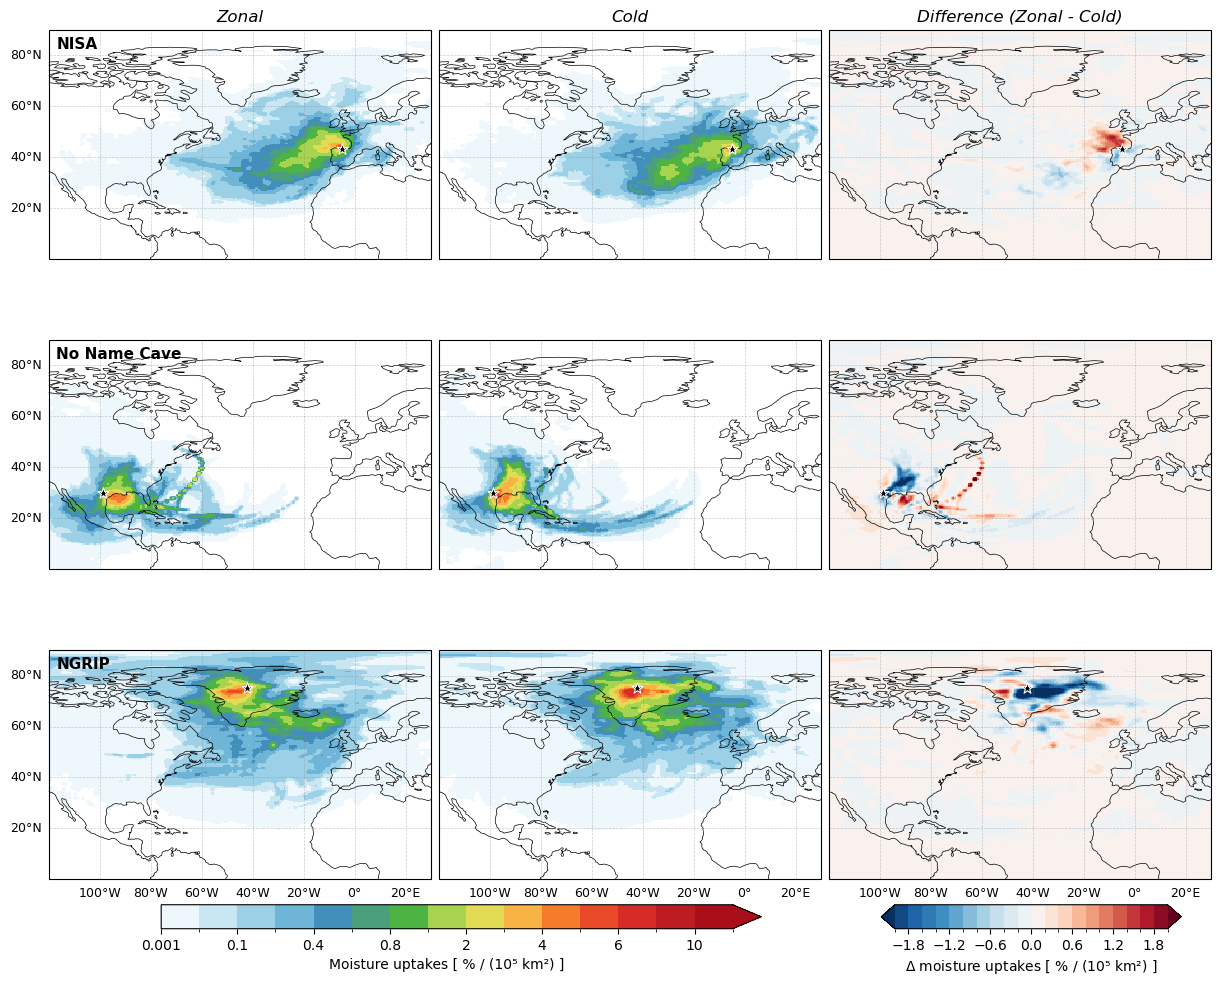

In [12]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib import colormaps
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable


# ============================================================
# SITE / CAVE INFORMATION
# ============================================================

sites = {
    "NISA_LaVallina": dict(
        lat=43.4100,
        lon=360 - 4.8067,
        traj_name="NISA",
    ),

    "NGRIP": dict(
        lat=75.1000,
        lon=360 - 42.3167,
        traj_name="NGRIP",
    ),

    "NonameCave": dict(
        lat=29.8700,
        lon=360 - 98.6269,
        traj_name="No Name Cave",
    ),
}


# ============================================================
# PROJECTION
# ============================================================

proj = ccrs.PlateCarree()
data_crs = ccrs.PlateCarree()


# ============================================================
# FIGURE / GRID
# ============================================================

fig = plt.figure(figsize=(15, 12))

gs = GridSpec(
    3, 3,
    figure=fig,
    wspace=0.02,
    hspace=0.02
)


# ============================================================
# COLORMAPS
# ============================================================

cmap_diff = colormaps["RdBu_r"]


# ------------------------------------------------------------
# Absolute uptake colormap
# ------------------------------------------------------------

colors = [
    "#eef8fc",
    "#c9e7f3",
    "#9bd0e7",
    "#6eb5d8",
    "#438fbb",
    "#4b9f7d",
    "#4db342",
    "#a8d34f",
    "#e2dc55",
    "#f7b344",
    "#f47c2b",
    "#e94a27",
    "#d72b25",
    "#bd1d22",
    "#a80f19",
]

cmap_main = ListedColormap(colors)
cmap_main.set_under("white")


# ============================================================
# ABSOLUTE UPTAKE NORMALIZATION
# ============================================================

levels = np.array([
    1e-3,   # 0.001
    0.06,
    0.1,    # 0.1
    0.25,
    0.4,    # 0.4
    0.6,
    0.8,    # 0.8
    1.2,
    2.0,    # 2
    3.0,
    4.0,    # 4
    5.0,
    6.0,    # 6
    8.0,
    10.0    # 10
])

norm_main = BoundaryNorm(
    levels,
    ncolors=cmap_main.N,
    extend="max"
)


# ============================================================
# DIFFERENCE NORMALIZATION
# ============================================================

diff_max = 2

diff_levels = np.linspace(
    -diff_max,
    diff_max,
    21
)

norm_diff = BoundaryNorm(
    diff_levels,
    ncolors=cmap_diff.N,
    extend="both"
)


# ============================================================
# GRIDLINE HELPER
# ============================================================

def add_gridlines(ax, i, j, nrows):

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        color="gray",
        alpha=0.4,
        linestyle="--"
    )

    # Latitude labels only on first column
    gl.left_labels = (j == 0)

    # Longitude labels only on bottom row
    gl.bottom_labels = (i == nrows - 1)

    # No labels on top/right
    gl.top_labels = False
    gl.right_labels = False

    gl.xlabel_style = {
        "size": 9
    }

    gl.ylabel_style = {
        "size": 9
    }

    return gl


# ============================================================
# PLOT
# ============================================================

for i, loc in enumerate(locations):

    # Site name from the sites dictionary
    site_name = sites[loc]["traj_name"]


    # --------------------------------------------------------
    # COLUMN 1: ZONAL
    # --------------------------------------------------------

    ax = fig.add_subplot(
        gs[i, 0],
        projection=proj
    )

    dataplot = data[loc]["xqeie"] * 1e7

    im0 = dataplot.plot(
        ax=ax,
        transform=data_crs,
        cmap=cmap_main,
        norm=norm_main,
        add_colorbar=False
    )

    ax.add_feature(
        cfeature.COASTLINE,
        linewidth=0.5
    )

    ax.set_extent(
        [-120, 30, 0, 90],
        crs=data_crs
    )

    # Column title
    if i == 0:
        ax.set_title(
            "Zonal",
            fontstyle="italic"
        )
    else:
        ax.set_title("")

    # Site name only on first column
    ax.text(
        0.02,
        0.97,
        site_name,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="top"
    )

    add_gridlines(
        ax,
        i,
        0,
        len(locations)
    )

    # Plot cave location
    ax.scatter(
        sites[loc]["lon"],
        sites[loc]["lat"],
        s=70,
        marker="*",
        facecolor="black",
        edgecolor="white",
        linewidth=0.8,
        transform=ccrs.PlateCarree(),
        zorder=10
    )


    # --------------------------------------------------------
    # COLUMN 2: COLD
    # --------------------------------------------------------

    ax = fig.add_subplot(
        gs[i, 1],
        projection=proj
    )

    dataplot = data[loc]["xqeic"] * 1e7

    im1 = dataplot.plot(
        ax=ax,
        transform=data_crs,
        cmap=cmap_main,
        norm=norm_main,
        add_colorbar=False
    )

    ax.add_feature(
        cfeature.COASTLINE,
        linewidth=0.5
    )

    ax.set_extent(
        [-120, 30, 0, 90],
        crs=data_crs
    )

    if i == 0:
        ax.set_title(
            "Cold",
            fontstyle="italic"
        )
    else:
        ax.set_title("")

    add_gridlines(
        ax,
        i,
        1,
        len(locations)
    )

    # Plot cave location
    ax.scatter(
        sites[loc]["lon"],
        sites[loc]["lat"],
        s=70,
        marker="*",
        facecolor="black",
        edgecolor="white",
        linewidth=0.8,
        transform=ccrs.PlateCarree(),
        zorder=10
    )


    # --------------------------------------------------------
    # COLUMN 3: DIFFERENCE
    # --------------------------------------------------------

    ax = fig.add_subplot(
        gs[i, 2],
        projection=proj
    )

    dataplot = data[loc]["diff"] * 1e7

    im2 = dataplot.plot(
        ax=ax,
        transform=data_crs,
        cmap=cmap_diff,
        norm=norm_diff,
        add_colorbar=False
    )

    ax.add_feature(
        cfeature.COASTLINE,
        linewidth=0.5
    )

    ax.set_extent(
        [-120, 30, 0, 90],
        crs=data_crs
    )

    if i == 0:
        ax.set_title(
            "Difference (Zonal - Cold)",
            fontstyle="italic"
        )
    else:
        ax.set_title("")

    add_gridlines(
        ax,
        i,
        2,
        len(locations)
    )

    # Plot cave location
    ax.scatter(
        sites[loc]["lon"],
        sites[loc]["lat"],
        s=70,
        marker="*",
        facecolor="black",
        edgecolor="white",
        linewidth=0.8,
        transform=ccrs.PlateCarree(),
        zorder=10
    )


# ============================================================
# COLORBARS
# ============================================================


# ------------------------------------------------------------
# ABSOLUTE UPTAKE COLORBAR
# Spans columns 1 + 2
# ------------------------------------------------------------

n_colors = cmap_main.N

# Display-only normalization:
# makes all 16 color blocks equally wide
legend_norm = BoundaryNorm(
    np.arange(n_colors + 1),
    ncolors=n_colors
)

cax_main = fig.add_axes([
    0.2,   # left
    0.10,   # bottom
    0.4,   # width: columns 1 + 2
    0.02    # height
])

cb_main = plt.colorbar(
    ScalarMappable(
        norm=legend_norm,
        cmap=cmap_main
    ),
    cax=cax_main,
    orientation="horizontal",
    extend="max"
)

# Labels at LEFT edge of selected color transitions
cb_main.set_ticks([
    0,
    2,
    4,
    6,
    8,
    10,
    12,
    14
])

cb_main.set_ticklabels([
    "0.001",
    "0.1",
    "0.4",
    "0.8",
    "2",
    "4",
    "6",
    "10"
])

cb_main.set_label(
    "Moisture uptakes [ % / (10⁵ km²) ]",
    color="black",
    fontsize=10
)

cb_main.ax.tick_params(
    labelcolor="black",
    colors="black"
)


# ------------------------------------------------------------
# DIFFERENCE COLORBAR
# Spans column 3 only
# ------------------------------------------------------------

cax_diff = fig.add_axes([
    0.68,   # left: start of column 3
    0.10,   # bottom
    0.20,   # width: column 3
    0.02    # height
])

cb_diff = plt.colorbar(
    ScalarMappable(
        norm=norm_diff,
        cmap=cmap_diff
    ),
    cax=cax_diff,
    orientation="horizontal",
    extend="both"
)

cb_diff.set_label(
    r"$\Delta$ moisture uptakes [ % / (10⁵ km²) ]",
    color="black",
    fontsize=10
)

cb_diff.ax.tick_params(
    labelcolor="black",
    colors="black"
)


# ============================================================
# SAVE / SHOW
# ============================================================

#plt.savefig(
#     "my_output/chapter-four_latestfigures/UTOT_th001_comparison_trajectories.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     pad_inches=0.05,
#     facecolor="white"
# )

plt.show()

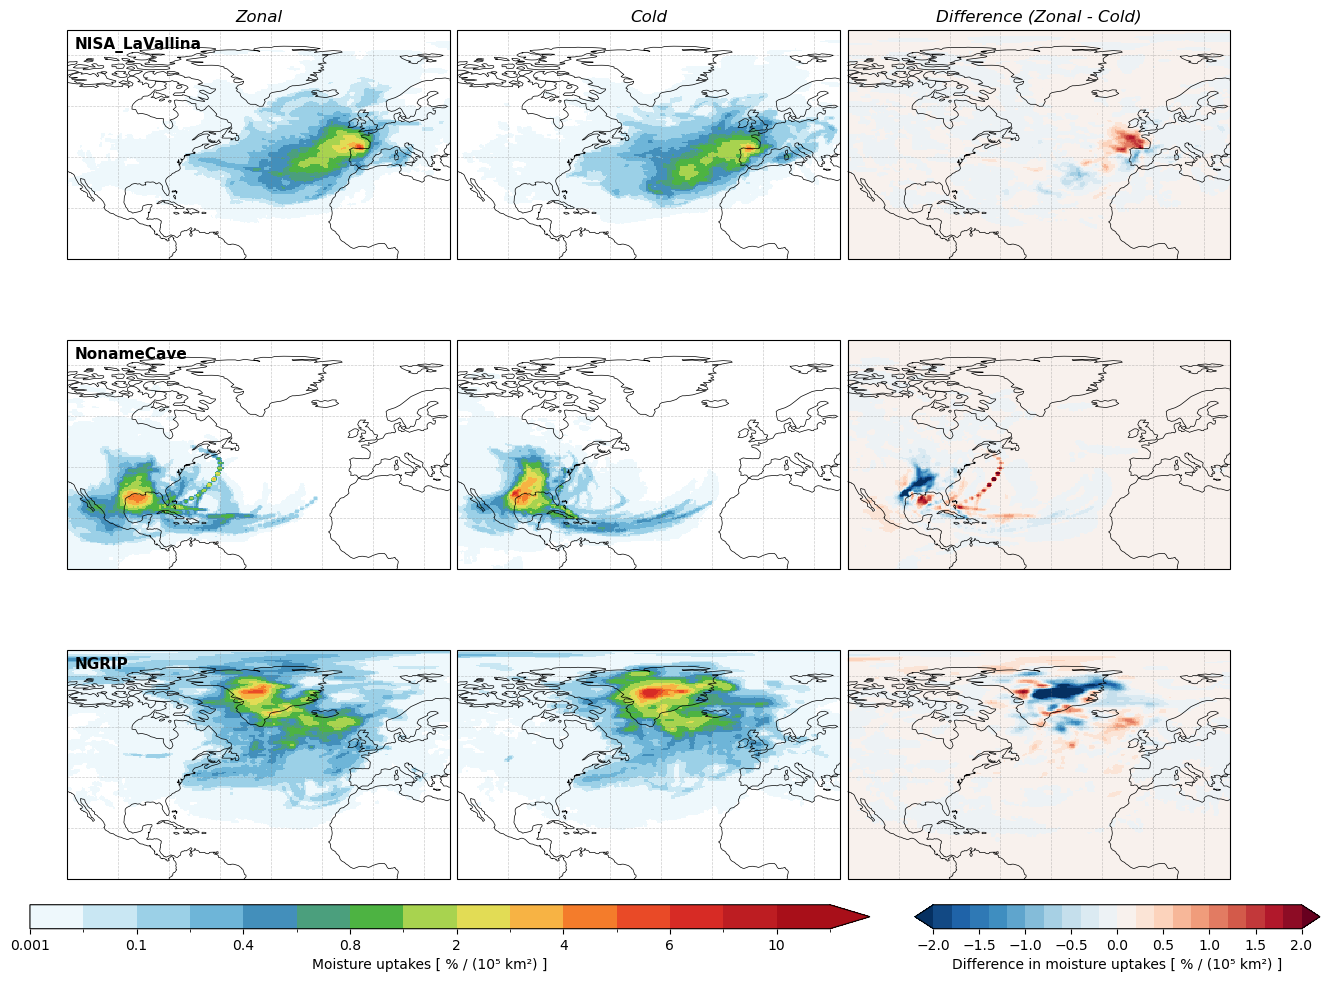

In [19]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import LogNorm
from matplotlib import colormaps
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable

# --- Define projection ---
proj = ccrs.NorthPolarStereo(central_longitude=-30)

proj = ccrs.PlateCarree()
data_crs = ccrs.PlateCarree()

# --- Plot setup ---
fig = plt.figure(figsize=(15, 12))
gs = GridSpec(3, 3, figure=fig, wspace=0.02, hspace=0.02)

# --- Colormap setup ---
cmap_main = cmc.batlowW_r #colormaps["Blues"]
cmap_diff = colormaps["RdBu_r"]

# --- Plot loop ---
#for i, loc in enumerate(locations):
    
# Determine color normalization for this row (independent for each site)
vmax = max(
        float(data[loc]["xqeie"].max()),
        float(data[loc]["xqeic"].max())
    )


#levels = np.linspace(10**(-9), vmax, 12)
#norm_main = BoundaryNorm(levels, ncolors=cmap_main.N, extend="both")

#vmin = 1e-9
#vmax = 1e-6  # adjust to your data
#norm_main = LogNorm(vmin=vmin, vmax=vmax)


# --- Create log-spaced levels ---
# --- Custom boundaries to reproduce the reference colorbar ---
levels = np.array([
    1e-3,   # 0.001
    0.06,
    0.1,    # reference label
    0.25,
    0.4,    # reference label
    0.6,
    0.8,    # reference label
    1.2,
    2.0,    # reference label
    3.0,
    4.0,    # reference label
    5.0,
    6.0,    # reference label
    8.0,
    10.0    # reference label
])

# 16 boundaries = 15 intervals


# --- 16 colors ---
colors = [
    "#eef8fc",
    "#c9e7f3",
    "#9bd0e7",
    "#6eb5d8",
    "#438fbb",
    "#4b9f7d",
    "#4db342",
    #"#7fc34c",
    "#a8d34f",
    "#e2dc55",
    "#f7b344",
    "#f47c2b",
    "#e94a27",
    "#d72b25",
    "#bd1d22",
    "#a80f19",
]

cmap_main = ListedColormap(colors)
cmap_main.set_under("white")


norm_main = BoundaryNorm(
    levels,
    ncolors=cmap_main.N,
    extend="max"
)


#diff_max = np.nanmax(np.abs(data[loc]["diff"]))
diff_max = 2
diff_levels = np.linspace(-diff_max, diff_max, 21)
norm_diff = BoundaryNorm(diff_levels, ncolors=cmap_diff.N, extend="both")


# --- Plot loop ---
for i, loc in enumerate(locations):
    # --- Column 1: Zonal (xqeie) ---
    ax = fig.add_subplot(gs[i, 0], projection=proj)
    dataplot = data[loc]["xqeie"]*1e7
    im0 = dataplot.plot(
        ax=ax, transform=data_crs, cmap=cmap_main, norm=norm_main, 
            add_colorbar=False
        )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_extent([-120, 30, 0, 90], crs=data_crs)
    if i == 0:
            ax.set_title("Zonal",fontstyle='italic')
    else:
            ax.set_title("")
    ax.text(0.02, 0.97, loc, transform=ax.transAxes, fontsize=11,
                fontweight='bold', va='top')
    gl = ax.gridlines(
        draw_labels=False,        # or True if you want lat/lon labels
        linewidth=0.5,
        color='gray',
        alpha=0.4,
        linestyle='--'
    )
    
    
    
    # --- Column 2: Cold (xqeic) ---
    ax = fig.add_subplot(gs[i, 1], projection=proj)
    dataplot = data[loc]["xqeic"]*1e7
    im1 = dataplot.plot(
            ax=ax, transform=data_crs, cmap=cmap_main, 
            norm=norm_main,
            add_colorbar=False)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_extent([-120, 30, 0, 90], crs=data_crs)
    if i == 0:
            ax.set_title("Cold",fontstyle="italic")
    else:
            ax.set_title("")
    
    gl = ax.gridlines(
        draw_labels=False,        # or True if you want lat/lon labels
        linewidth=0.5,
        color='gray',
        alpha=0.4,
        linestyle='--'
    )
    
    
    # --- Column 3: Difference (xqeie - xqeic) ---
    ax = fig.add_subplot(gs[i, 2], projection=proj)
    dataplot = data[loc]["diff"]*1e7
    im2 = dataplot.plot(
            ax=ax, transform=data_crs, cmap=cmap_diff, norm=norm_diff,
            add_colorbar=False)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_extent([-120, 30, 0, 90], crs=data_crs)
    if i == 0:
            ax.set_title("Difference (Zonal - Cold)",fontstyle="italic")
    else:
            ax.set_title("")
    
    gl = ax.gridlines(
        draw_labels=False,        # or True if you want lat/lon labels
        linewidth=0.5,
        color='gray',
        alpha=0.4,
        linestyle='--'
    )

#### Colorbars

# 16 equally spaced color bins for the DISPLAY ONLY
n_colors = cmap_main.N

legend_norm = BoundaryNorm(
    np.arange(n_colors + 1),
    ncolors=n_colors
)

# Main olorbar
# Position: columns 1 + 2
cax_main = fig.add_axes([
    0.10,   # left
    0.10,   # bottom
    0.56,   # width  -> columns 1 + 2
    0.02    # height
])

cb_main = plt.colorbar(
    ScalarMappable(norm=legend_norm, cmap=cmap_main),
    cax=cax_main,
    orientation="horizontal",
    extend='max'
)

# 8 labels, evenly spaced along the colorbar
# Labels at the LEFT edge of the color changes
# (i.e. at color-bin boundaries)
cb_main.set_ticks([
    0,      # left edge of color 1
    2,      # left edge of color 3
    4,      # left edge of color 5
    6,      # left edge of color 7
    8,      # left edge of color 9
    10,     # left edge of color 11
    12,     # left edge of color 13
    14      # left edge of color 15
])


cb_main.set_ticklabels([
    "0.001", "0.1", "0.4", "0.8",
    "2", "4", "6", "10"
])

# Label
cb_main.set_label(
    "Moisture uptakes [ % / (10⁵ km²) ]",
    color="black",
    fontsize=10
)

cb_main.ax.tick_params(
    labelcolor="black",
    colors="black"
)

# ============================================================
# Difference colorbar — spans column 3 only
# ============================================================

cax_diff = fig.add_axes([
    0.69,   # left -> start of column 3
    0.10,   # bottom
    0.27,   # width -> column 3
    0.02    # height
])

cb_diff = plt.colorbar(
    ScalarMappable(norm=norm_diff, cmap=cmap_diff),
    cax=cax_diff,
    orientation='horizontal',
    extend='both')

# --- Customize ticks and labels ---
cb_diff.set_label("Difference in moisture uptakes [ % / (10⁵ km²) ]", color="black", fontsize=10)
cb_diff.ax.tick_params(labelcolor='black', colors='black')
cb_diff.ax.set_xscale('linear')

#plt.suptitle("Precipitation-weighted UTOT fields for three locations", fontsize=14, y=0.93)
#plt.show()

### SAVE
#plt.savefig(
#    "my_output/chapter-four_latestfigures/UTOT_th001_comparison_trajectories.pdf", 
#    dpi=300,                # high resolution for publication
#    bbox_inches='tight',    # include all axes, labels, colorbars
#    pad_inches=0.05,        # small padding around edges
#    facecolor='white'       # ensures background is white, not transparent
#)


In [7]:
# Export the the regridded data as a mask.

import xarray as xr
import numpy as np

ds_dye_zonal = xr.open_dataset('myintermediates/dyestuff_modelpaper/mean_dye_zonal.nc')
lat_new = ds_dye_zonal.lat
lon_new = ds_dye_zonal.lon  # 0 → 360

da_regridded = {}

for loc in data:
    da_regridded[loc] = {}
    for mode in data[loc]:
        da = data[loc][mode].copy()

        # --- Wrap lon to 0–360 ---
        if (da.lon < 0).any():
            da = da.assign_coords(lon=da.lon % 360)
            da = da.sortby("lon")

            # --- Drop duplicate longitudes (keep the first occurrence) ---
            _, unique_idx = np.unique(da.lon, return_index=True)
            da = da.isel(lon=np.sort(unique_idx))

        # --- Interpolate to new grid ---
        da_interp = da.interp(lat=lat_new, lon=lon_new, method="linear")

        # --- Preserve metadata ---
        da_interp.name = da.name + "_1p25deg"
        da_interp.attrs.update({
            "description": "Regridded to HadCM3-style 1.25° grid centers (0–360 lon)",
            "units": da.attrs.get("units", "% / 1e5 km²"),
            "note": "Source longitude wrapped from -180..180 to 0..360 before interpolation; duplicates removed"
        })

        da_regridded[loc][mode] = da_interp

print("✅ Regridding complete. Which locations:", list(da_regridded.keys())[:3])



✅ Regridding complete. Which locations: ['NISA', 'NoNameCave', 'NGRIP']


In [10]:
# Export the uptake mask as intermediate product
import pickle

with open("myintermediates/dyestuff_modelpaper/land_uptakemasks.pkl", "wb") as f:
    pickle.dump(da_regridded, f, protocol=pickle.HIGHEST_PROTOCOL)

